In [1]:
import os
import pickle
import torch
from torch.utils.data import Dataset
import random

AA_TO_INDEX = {
    'A': 0, 'C': 1, 'D': 2, 'E': 3, 'F': 4,
    'G': 5, 'H': 6, 'I': 7, 'K': 8, 'L': 9,
    'M': 10, 'N': 11, 'P': 12, 'Q': 13, 'R': 14,
    'S': 15, 'T': 16, 'V': 17, 'W': 18, 'Y': 19,
    '-': 20, 'X': 20  # padding 또는 unknown
}

def random_voxel_rotate(voxel):
    # voxel: Tensor [C, D, H, W]
    if random.random() < 0.5:  # 50% 확률로 회전 적용
        axes = [(2, 3), (1, 3), (1, 2)]  # (H, W), (D, W), (D, H)
        k = random.choice([1, 2, 3])  # 실제 회전만 (0 제외)
        axis = random.choice(axes)
        voxel = torch.rot90(voxel, k=k, dims=axis)
    return voxel

def random_voxel_flip(voxel):
    if random.random() < 0.5:
        voxel = torch.flip(voxel, dims=[1])  # D-axis flip
    if random.random() < 0.5:
        voxel = torch.flip(voxel, dims=[2])  # H-axis flip
    if random.random() < 0.5:
        voxel = torch.flip(voxel, dims=[3])  # W-axis flip
    return voxel

class VoxelDataset(Dataset):
    def __init__(self, df, voxel_cache_dir, aug=False):
        self.df = df.reset_index(drop=True)
        self.voxel_cache_dir = voxel_cache_dir
        self.aug = aug

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        uid = row["UniProtID"]
        mut_pos = row["MutPos(pdb)"]
        wt = row["WT"]
        mut = row["Mut"]
        label = row["Label"]

        key = f"{uid}_{mut_pos}"
        voxel_path = os.path.join(self.voxel_cache_dir, f"{key}.pkl")

        # Load voxel
        with open(voxel_path, "rb") as f:
            data = pickle.load(f)
            feature = data["feature"]  # shape: (1, 7, 7, 7, 63)

        # Preprocess
        feature_tensor = torch.from_numpy(feature).permute(0, 4, 1, 2, 3).float().squeeze(0)  # (63, 7, 7, 7)

        if self.aug:
            feature_tensor = random_voxel_rotate(feature_tensor)
            feature_tensor = random_voxel_flip(feature_tensor)

        # Convert WT/Mut AA to index
        ref_idx = torch.tensor(AA_TO_INDEX.get(str(wt), 20), dtype=torch.long)
        mut_idx = torch.tensor(AA_TO_INDEX.get(str(mut), 20), dtype=torch.long)

        return feature_tensor, ref_idx, mut_idx, torch.tensor(label).long()
    
class MSADataset(Dataset):
    def __init__(self, df, msa_dict_path, max_depth=80, win_size=61, aug=False):
        with open(msa_dict_path, "rb") as f:
            self.msa_dict = pickle.load(f)
        self.df = df
        self.max_depth = max_depth
        self.win_size = win_size
        self.half_win = win_size // 2  # 중심에서 양쪽 길이
        self.aug = aug
        
    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        uid = row["UniProtID"]
        mut_pos = int(row["MutPos"]) - 1  # 1-based → 0-based
        label = int(row["Label"])
        mut = row["Mut"].upper()

        msa_seqs = [seq for _, seq in self.msa_dict[uid][:self.max_depth]]
        query_seq = msa_seqs[0]  # 보통 첫 줄이 ref seq

        # 변이 반영된 mut_seq 생성
        mut_seq = list(query_seq)
        if 0 <= mut_pos < len(mut_seq):
            mut_seq[mut_pos] = mut

        # 사용될 시퀀스: 변이 시퀀스 + ref 시퀀스 + MSA
        seqs_to_use = [mut_seq, list(query_seq)]
        if len(msa_seqs) > 1:
            seqs_to_use += [list(seq) for seq in msa_seqs[1:self.max_depth - 2]]

        if self.aug:
            msa_part = seqs_to_use[2:]  # 변이+ref 제외
            random.shuffle(msa_part)   # 순서 섞기
            seqs_to_use = seqs_to_use[:2] + msa_part

        centered_msa = []
        for seq in seqs_to_use:
            window = []
            for i in range(self.win_size):
                seq_idx = mut_pos - self.half_win + i
                if 0 <= seq_idx < len(seq):
                    aa = seq[seq_idx]
                else:
                    aa = '-'
                window.append(AA_TO_INDEX.get(aa, 20))
            centered_msa.append(window)

        # depth padding
        while len(centered_msa) < self.max_depth:
            centered_msa.append([20] * self.win_size)  # 20은 패딩 인덱스

        msa_tensor = torch.tensor(centered_msa[:self.max_depth]).long()  # [D, L]
        msa_tensor = msa_tensor.transpose(0, 1)  # [L, D]

        return {
            "msa": msa_tensor,  # [L, D]
            "label": torch.tensor(label).long()
        }

class MultimodalDataset(Dataset):
    def __init__(self, df, voxel_cache_dir, msa_dict_path, 
                 voxel_aug=False, msa_aug=False, max_depth=80, win_size=61):
        self.df = df.reset_index(drop=True)
        self.voxel_dataset = VoxelDataset(df, voxel_cache_dir, aug=voxel_aug)
        self.msa_dataset = MSADataset(df, msa_dict_path, max_depth=max_depth, win_size=win_size, aug=msa_aug)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        voxel_feat, ref_idx, mut_idx, label = self.voxel_dataset[idx]
        msa_data = self.msa_dataset[idx]  # returns dict with "msa", "label"
        msa_tensor = msa_data["msa"]
        
        # 라벨 일치 확인 (안전용)
        assert label == msa_data["label"], "Mismatch in label!"

        return {
            "voxel": voxel_feat,      # [63, 7, 7, 7]
            "ref_idx": ref_idx,
            "mut_idx": mut_idx,
            "msa": msa_tensor,        # [L=61, D]
            "label": label
        }

In [2]:
import torch
import torch.nn as nn
from mamba_ssm import Mamba
import torch.nn.functional as F
import numpy as np


# --- Input Embedding ---
class MSAInputEmbedding(nn.Module):
    def __init__(self, vocab_size=21, dim=256):
        super().__init__()
        self.embedding = nn.Embedding(num_embeddings=vocab_size, embedding_dim=dim)

    def forward(self, x):  # x: (B, L, D)
        return self.embedding(x)  # → (B, L, D, C)

# --- Cross-Axial Mamba Block ---
class CrossAxialMambaMSA(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.norm_L = nn.RMSNorm(dim, eps=1e-8)
        self.norm_D = nn.RMSNorm(dim, eps=1e-8)

        self.mamba_L = Mamba(d_model=dim, expand=1)
        self.conv_D = nn.Sequential(
            nn.Conv1d(dim, dim, kernel_size=5, padding=2),
            nn.SiLU()
        )

    def forward(self, x):  # x: (B, L, D, C)
        B, L, D, C = x.shape
        center_L = L // 2  # = 30

        # --- D-axis: only at center L position ---
        x_d_center = self.norm_D(x[:, center_L])  # (B, D, C)
        x_d = x_d_center.transpose(1, 2)          # (B, C, D)
        d_out = self.conv_D(x_d).transpose(1, 2).unsqueeze(1)  # (B, 1, D, C)

        # --- L-axis: full Mamba ---
        x_l = self.norm_L(x).permute(0, 2, 1, 3).contiguous().view(B * D, L, C)
        l_out = self.mamba_L(x_l).view(B, D, L, C).permute(0, 2, 1, 3)  # (B, L, D, C)

        # --- Residual ---
        # d_out is only for center, rest is zero
        d_full = torch.zeros_like(x)
        d_full[:, center_L:center_L+1] = d_out

        return x + d_full + l_out
    
# # --- Encoder ---
class MSAEncoder(nn.Module):
    def __init__(self, num_layers=8, dim=256):
        super().__init__()
        self.embeddings = MSAInputEmbedding(dim=dim)
        self.blocks = nn.ModuleList([
            CrossAxialMambaMSA(dim) for _ in range(num_layers)
        ])
        self.norm_f = nn.RMSNorm(dim, eps=1e-8)

    def forward(self, x):  # x: (B, L, D)
        x = self.embeddings(x)  # → (B, L, D, C)
        for block in self.blocks:
            x = block(x)
        return self.norm_f(x)  # (B, L, D, C)


class SqueezeExcitation3D(nn.Module):
    def __init__(self, in_channels, reduction=24):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool3d(1)
        self.se = nn.Sequential(
            nn.Conv3d(in_channels, in_channels // reduction, kernel_size=1),
            nn.SiLU(),
            nn.Conv3d(in_channels // reduction, in_channels, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        scale = self.se(self.pool(x))
        return x * scale

class MBConv3D(nn.Module):
    def __init__(self, in_ch, out_ch, expand_ratio=6, kernel_size=3, stride=1, se_reduction=16):
        super().__init__()
        mid_ch = in_ch * expand_ratio

        self.use_res_connect = (stride == 1 and in_ch == out_ch)

        self.expand = nn.Sequential(
            nn.Conv3d(in_ch, mid_ch, kernel_size=1, bias=False),
            nn.BatchNorm3d(mid_ch),
            nn.SiLU()
        ) if expand_ratio != 1 else nn.Identity()

        self.depthwise = nn.Sequential(
            nn.Conv3d(mid_ch, mid_ch, kernel_size=kernel_size, stride=stride,
                      padding=kernel_size//2, groups=mid_ch, bias=False),
            nn.BatchNorm3d(mid_ch),
            nn.SiLU()
        )

        self.se = SqueezeExcitation3D(mid_ch, reduction=se_reduction)

        self.project = nn.Sequential(
            nn.Conv3d(mid_ch, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm3d(out_ch)
        )

    def forward(self, x):
        identity = x
        out = self.expand(x)
        out = self.depthwise(out)
        out = self.se(out)
        out = self.project(out)

        if self.use_res_connect:
            return out + identity
        else:
            return out

import torch
import torch.nn as nn
import torch.nn.functional as F

class h_sigmoid(nn.Module):
    def __init__(self, inplace=True):
        super().__init__()
        self.relu = nn.ReLU6(inplace=inplace)

    def forward(self, x):
        return self.relu(x + 3) / 6

class h_swish(nn.Module):
    def __init__(self, inplace=True):
        super().__init__()
        self.sigmoid = h_sigmoid(inplace=inplace)

    def forward(self, x):
        return x * self.sigmoid(x)

class CoordAtt3D(nn.Module):
    def __init__(self, inp, oup, reduction=16):
        super().__init__()
        # 축별 pooling
        self.pool_d = nn.AdaptiveAvgPool3d((None, 1, 1))  # keep D
        self.pool_h = nn.AdaptiveAvgPool3d((1, None, 1))  # keep H
        self.pool_w = nn.AdaptiveAvgPool3d((1, 1, None))  # keep W

        mip = max(8, inp // reduction)

        self.conv1 = nn.Conv3d(inp, mip, kernel_size=1, stride=1, padding=0)
        self.bn1 = nn.BatchNorm3d(mip)
        self.act = h_swish()

        # 축별 복원 conv
        self.conv_d = nn.Conv3d(mip, oup, kernel_size=1, stride=1, padding=0)
        self.conv_h = nn.Conv3d(mip, oup, kernel_size=1, stride=1, padding=0)
        self.conv_w = nn.Conv3d(mip, oup, kernel_size=1, stride=1, padding=0)

    def forward(self, x):
        identity = x
        B, C, D, H, W = x.size()

        # --- 축별 pooling ---
        x_d = self.pool_d(x)  # [B,C,D,1,1]
        x_h = self.pool_h(x)  # [B,C,1,H,1]
        x_w = self.pool_w(x)  # [B,C,1,1,W]

        # 축 정렬을 위해 permute
        x_h = x_h.permute(0, 1, 3, 2, 4)  # [B,C,H,1,1]
        x_w = x_w.permute(0, 1, 4, 2, 3)  # [B,C,W,1,1]

        # concat along "length" dimension
        y = torch.cat([x_d, x_h, x_w], dim=2)  # [B,C,D+H+W,1,1]
        y = self.conv1(y)
        y = self.bn1(y)
        y = self.act(y)

        # 다시 split
        x_d, x_h, x_w = torch.split(y, [D, H, W], dim=2)

        # 축 되돌리기
        x_h = x_h.permute(0, 1, 3, 2, 4)  # [B,C,1,H,1]
        x_w = x_w.permute(0, 1, 3, 4, 2)  # [B,C,1,1,W]

        # attention map
        a_d = self.conv_d(x_d).sigmoid()  # [B,C,D,1,1]
        a_h = self.conv_h(x_h).sigmoid()  # [B,C,1,H,1]
        a_w = self.conv_w(x_w).sigmoid()  # [B,C,1,1,W]

        out = identity * a_d * a_h * a_w
        return out

    
class VoxelBranch(nn.Module):
    def __init__(self, in_ch=63, emb_dim=128):
        super().__init__()
        
        # 3D 구조 백본
        self.backbone = nn.Sequential(
            MBConv3D(in_ch, 32, expand_ratio=6),     # [7×7×7]
            MBConv3D(32, 32, expand_ratio=6),
            MBConv3D(32, 48, expand_ratio=6),
            MBConv3D(48, 48, expand_ratio=6),
            MBConv3D(48, 64, expand_ratio=6),
            MBConv3D(64, 64, expand_ratio=6, stride=2),  # 다운샘플링: → [4×4×4]
            MBConv3D(64, 64, expand_ratio=6),
            MBConv3D(64, 96, expand_ratio=6),
            MBConv3D(96, 96, expand_ratio=6),
            MBConv3D(96, 96, expand_ratio=6),
            MBConv3D(96, 96, expand_ratio=6),
            MBConv3D(96, 96, expand_ratio=6),
            MBConv3D(96, emb_dim, expand_ratio=6),
            MBConv3D(emb_dim, emb_dim, expand_ratio=6),
            MBConv3D(emb_dim, emb_dim, expand_ratio=6)
        )

        self.coordatt = CoordAtt3D(emb_dim, emb_dim)

        self.pool = nn.AdaptiveAvgPool3d(1)  # → [B, 128, 1, 1, 1]

        # Mutation Embedding (64 + 64 → 128)
        self.ref_emb = nn.Embedding(21, emb_dim // 2)  # 64
        self.mut_emb = nn.Embedding(21, emb_dim // 2)  # 64
        self.mut_fusion = nn.Sequential(
            nn.Linear(emb_dim, emb_dim),
            nn.BatchNorm1d(emb_dim),
            nn.SiLU(),
            nn.Linear(emb_dim, emb_dim),
            nn.BatchNorm1d(emb_dim),
            nn.SiLU()
        )

        self.refine = nn.Sequential(
            nn.Linear(emb_dim, emb_dim),
            nn.BatchNorm1d(emb_dim),
            nn.SiLU()
        )

    def forward(self, x, ref_idx, mut_idx):
        x = self.backbone(x)               # [B, 128, 7, 7, 7]
        x = self.coordatt(x) 
        x = self.pool(x).squeeze(-1).squeeze(-1).squeeze(-1)  # → [B, 128]

        # Mutation embedding
        ref_vec = self.ref_emb(ref_idx)    # [B, 64]
        mut_vec = self.mut_emb(mut_idx)    # [B, 64]
        mut_feat = self.mut_fusion(torch.cat([ref_vec, mut_vec], dim=1))  # [B, 128]

        # Combine structure & mutation features
        x = x + mut_feat                   # [B, 128]

        return self.refine(x)       # [B, 128]


class CenterAwarePooling(nn.Module):
    def __init__(self, dim, num_heads=4):
        super().__init__()
        self.attn = nn.MultiheadAttention(embed_dim=dim, num_heads=num_heads, batch_first=True)

    def forward(self, x):  # x: (B, L, D, C)
        B, L, D, C = x.shape
        center_L = L // 2

        # Query: center residue [B,D,C] → [B*D,1,C]
        query = x[:, center_L].reshape(B * D, 1, C)

        # Key/Value: 전체 window [B,L,D,C] → [B*D,L,C]
        keyval = x.permute(0, 2, 1, 3).reshape(B * D, L, C)

        # Attention
        attn_out, _ = self.attn(query, keyval, keyval)  # [B*D,1,C]

        # Depth 방향 평균 → [B,C]
        pooled = attn_out.view(B, D, C).mean(dim=1)
        return pooled
    
class MSABranch(nn.Module):
    def __init__(self, num_layers=4, dim=128):
        super().__init__()
        self.encoder = MSAEncoder(num_layers=num_layers, dim=dim)
        self.pooling = CenterAwarePooling(dim, num_heads=4)

        self.refine = nn.Sequential(
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
            nn.SiLU()
        )

    def forward(self, x):  # x: (B,L,D)
        x = self.encoder(x)        # [B,L,D,C]
        x = self.pooling(x)        # [B,C]  ← center+context 반영
        return self.refine(x)      # [B,C]
    
class EvoStructCLIP(nn.Module):
    def __init__(self, voxel_ch=63, mb_layers=8, embed_dim=128, dropout_p=0.3):
        super().__init__()
        self.voxel_encoder = VoxelBranch(in_ch=voxel_ch, emb_dim=embed_dim)
        self.msa_encoder = MSABranch(num_layers=mb_layers, dim=embed_dim)

        # log(1 / 0.07) ≈ 2.6592 → exp(logit_scale) ≈ 14.2857
        self.logit_scale = nn.Parameter(torch.ones([]) * np.log(1 / 0.07))

        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, embed_dim),
            nn.BatchNorm1d(embed_dim),
            nn.SiLU(),
            nn.Dropout(dropout_p),
            nn.Linear(embed_dim, 1)
        )

    def _get_vector_norm(self, tensor):
        return F.normalize(tensor, dim=-1, eps=1e-8)

    def forward(self, voxel, ref_idx, mut_idx, msa, inference_only=False):

        if inference_only:
            # msa-only
            msa_feat = self.msa_encoder(msa)   # [B,128]
            logits = self.classifier(msa_feat) # [B,1]
            return {
                "logits": logits,
                "msa_feat": msa_feat
            }
        
        # Raw features
        voxel_feat = self.voxel_encoder(voxel, ref_idx, mut_idx)  # [B, 128]
        msa_feat = self.msa_encoder(msa)                          # [B, 128]

        voxel_embeds = F.normalize(voxel_feat, dim=-1, eps=1e-8)
        msa_embeds   = F.normalize(msa_feat, dim=-1, eps=1e-8)

        logits_per_voxel = torch.matmul(voxel_embeds, msa_embeds.t())
        logits_per_voxel = logits_per_voxel * self.logit_scale.exp().to(voxel_embeds.device)
        logits_per_msa = logits_per_voxel.t() 

        # msa-only classification
        logits = self.classifier(msa_feat)

        return {
            "logits": logits,
            "logits_per_msa": logits_per_msa,
            "logits_per_voxel": logits_per_voxel,
            "voxel_feat": voxel_feat,
            "msa_feat": msa_feat
        }

/home/kunny/miniconda3/envs/mamba_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from torch.utils.data import DataLoader
import pandas as pd
from sklearn.model_selection import KFold

df = pd.read_csv(r"/mnt/c/Users/Kunny/Research/Project/BiConVarNet/filtered_variants_cleaned_final.tsv", sep="\t", )

# 10-fold 
kf = KFold(n_splits=10, shuffle=True, random_state=42)
splits = list(kf.split(df))
train_idx, val_idx = splits[0]

train_df = df.iloc[train_idx].copy()
val_df = df.iloc[val_idx].copy()

# oversampling: label == 1
pos_df = train_df[train_df["Label"] == 1]  
neg_df = train_df[train_df["Label"] == 0]

repeat_factor = max(1, len(neg_df) // max(len(pos_df), 1))
oversampled_train_df = pd.concat([neg_df, pd.concat([pos_df] * repeat_factor)], ignore_index=True)
oversampled_train_df = oversampled_train_df.sample(frac=1, random_state=42).reset_index(drop=True)  # 셔플

from torch.utils.data import DataLoader
        
voxel_cache_dir = "/mnt/e/CAGI_data/voxel_cache_4_noRSA"
msa_dict_path = "/mnt/e/CAGI_data/msa_dict_valid_new.pkl"

# train_dataset = MultimodalDataset(oversampled_train_df, voxel_cache_dir, msa_dict_path, voxel_aug=False, msa_aug=False)
# val_dataset   = MultimodalDataset(val_df, voxel_cache_dir, msa_dict_path)

# train_loader = DataLoader(train_dataset, batch_size=88, shuffle=True, num_workers=4, persistent_workers=True, pin_memory=True)
# val_loader   = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=4, persistent_workers=True, pin_memory=True)

test_dataset = MSADataset(val_df, msa_dict_path)
test_loader = DataLoader(test_dataset, batch_size=500, shuffle=False, num_workers=4, persistent_workers=True, pin_memory=True)

In [4]:
# 전체 분포
print("=== 전체 데이터 분포 ===")
print(df["Label"].value_counts(normalize=True))  # 비율
print(df["Label"].value_counts())                # 개수

# train 분포
print("\n=== Train 데이터 분포 ===")
print(train_df["Label"].value_counts(normalize=True))
print(train_df["Label"].value_counts())

# val 분포
print("\n=== Validation 데이터 분포 ===")
print(val_df["Label"].value_counts(normalize=True))
print(val_df["Label"].value_counts())


=== 전체 데이터 분포 ===
Label
0    0.664068
1    0.335932
Name: proportion, dtype: float64
Label
0    102125
1     51662
Name: count, dtype: int64

=== Train 데이터 분포 ===
Label
0    0.664174
1    0.335826
Name: proportion, dtype: float64
Label
0    91927
1    46481
Name: count, dtype: int64

=== Validation 데이터 분포 ===
Label
0    0.663112
1    0.336888
Name: proportion, dtype: float64
Label
0    10198
1     5181
Name: count, dtype: int64


In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import average_precision_score, roc_auc_score, accuracy_score
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = EvoStructCLIP(voxel_ch=46, mb_layers=6, embed_dim=128, dropout_p=0.3).to(device)

# --- Binary classification (output: [B, 1]) + CLIP   
criterion = nn.BCEWithLogitsLoss()  # sigmoid + BCE
lr = 1e-3

optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)

num_epochs = 100
best_pr_auc = 0.0
save_path = "/mnt/e/CAGI_data/best_model_250904_clip_2.pth"

# --- Contrastive loss
def contrastive_loss(logits: torch.Tensor) -> torch.Tensor:
    return F.cross_entropy(logits, torch.arange(len(logits), device=logits.device))

def compute_clip_loss(similarity: torch.Tensor) -> torch.Tensor:
    return (contrastive_loss(similarity) + contrastive_loss(similarity.t())) / 2

def fusemix(voxel_feat, msa_feat, alpha=0.4):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(voxel_feat.size(0), device=voxel_feat.device)

    voxel_feat_shuffled = voxel_feat[idx]
    msa_feat_shuffled = msa_feat[idx]

    voxel_mix = lam * voxel_feat + (1 - lam) * voxel_feat_shuffled
    msa_mix = lam * msa_feat + (1 - lam) * msa_feat_shuffled

    return voxel_mix, msa_mix

def get_loss_weights(epoch, T_max):
    # epoch 진행률 (0~1)
    progress = epoch / T_max
    
    w_cls = 1.0 - 0.3 * progress          # 1.0 → 0.7
    
    w_clip = 0.2 + 0.8 * progress          # 0.2 → 1.0
    
    w_mix = 0.1 + 0.9 * (0.5 - 0.5 * np.cos(np.pi * progress))  
    # 0.1 → 1.0 (cosine ramp-up)
    
    return w_cls, w_clip, w_mix

# --- Train Loop
for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1} [Train]"):
        voxel = batch["voxel"].to(device)
        ref_idx = batch["ref_idx"].to(device)
        mut_idx = batch["mut_idx"].to(device)
        msa = batch["msa"].to(device)
        label = batch["label"].float().to(device)  # BCE → float

        optimizer.zero_grad()

        out = model(voxel, ref_idx, mut_idx, msa)
        logits = out["logits"].squeeze(-1)  # [B]
        cls_loss = criterion(logits, label)

        clip_loss_val = compute_clip_loss(out["logits_per_voxel"])

        voxel_mix, msa_mix = fusemix(out["voxel_feat"], out["msa_feat"])

        voxel_mix_norm = F.normalize(voxel_mix, dim=-1, eps=1e-8)
        msa_mix_norm   = F.normalize(msa_mix, dim=-1, eps=1e-8)

        logits_per_voxel_mix = torch.matmul(voxel_mix_norm, msa_mix_norm.T) * model.logit_scale.exp()
        loss_mix = compute_clip_loss(logits_per_voxel_mix)

        w_cls, w_clip, w_mix = get_loss_weights(epoch, T_max=50)
        total_loss = w_cls * cls_loss + w_clip * clip_loss_val + w_mix * loss_mix

        total_loss.backward()
        optimizer.step()
        train_loss += total_loss.item() * voxel.size(0)

    scheduler.step()
    avg_train_loss = train_loss / len(train_loader.dataset)

    # --- Validation ---
    model.eval()
    val_loss = 0
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"Epoch {epoch+1} [Val]"):
            voxel = batch["voxel"].to(device)
            ref_idx = batch["ref_idx"].to(device)
            mut_idx = batch["mut_idx"].to(device)
            msa = batch["msa"].to(device)
            label = batch["label"].float().to(device)

            out = model(voxel, ref_idx, mut_idx, msa)
            logits = out["logits"].squeeze(-1)  # [B]
            loss = criterion(logits, label)

            probs = torch.sigmoid(logits)  # [B]

            val_loss += loss.item() * voxel.size(0)
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(label.cpu().numpy())

    # --- Metric 계산 ---
    avg_val_loss = val_loss / len(val_loader.dataset)
    pr_auc = average_precision_score(all_labels, all_probs)
    roc_auc = roc_auc_score(all_labels, all_probs)

    # 0.5 기준 이진 분류
    preds = [1 if p >= 0.5 else 0 for p in all_probs]
    acc = accuracy_score(all_labels, preds)

    # --- 출력 ---
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    print(f"Val PR-AUC: {pr_auc:.4f} | ROC-AUC: {roc_auc:.4f} | Accuracy: {acc:.4f}")

    if pr_auc > best_pr_auc:  
        best_pr_auc = pr_auc
        torch.save(model.state_dict(), save_path)
        print(f">>> Best model saved! PR-AUC: {pr_auc:.4f}")
        

Epoch 1 [Val]: 100%|██████████| 962/962 [00:38<00:00, 25.14it/s]



Epoch 1/100
Train Loss: 0.6930 | Val Loss: 0.3843
Val PR-AUC: 0.8425 | ROC-AUC: 0.9086 | Accuracy: 0.8299
>>> Best model saved! PR-AUC: 0.8425


Epoch 2 [Val]: 100%|██████████| 962/962 [00:35<00:00, 27.07it/s]



Epoch 2/100
Train Loss: 0.4512 | Val Loss: 0.3403
Val PR-AUC: 0.8799 | ROC-AUC: 0.9282 | Accuracy: 0.8532
>>> Best model saved! PR-AUC: 0.8799


Epoch 3 [Val]: 100%|██████████| 962/962 [00:36<00:00, 26.68it/s]


...


Epoch 45/100
Train Loss: 0.0430 | Val Loss: 0.6993
Val PR-AUC: 0.9014 | ROC-AUC: 0.9400 | Accuracy: 0.8653


Epoch 46 [Val]: 100%|██████████| 962/962 [00:34<00:00, 28.03it/s]



Epoch 46/100
Train Loss: 0.0420 | Val Loss: 0.8199
Val PR-AUC: 0.9008 | ROC-AUC: 0.9407 | Accuracy: 0.8631


Epoch 47 [Train]:   8%|▊         | 126/1573 [01:18<14:57,  1.61it/s]


KeyboardInterrupt: 

In [4]:
import torch
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, precision_recall_curve, roc_auc_score, average_precision_score

# --- Load best model ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = EvoStructCLIP(voxel_ch=46, mb_layers=6, embed_dim=128, dropout_p=0.3).to(device)
model.load_state_dict(torch.load("/mnt/e/CAGI_data/best_model_250904_clip_2.pth", map_location=device))
model.eval()

all_probs = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:

        msa = batch["msa"].to(device)
        label = batch["label"].float().to(device)

        out = model(None, None, None, msa, inference_only=True)
        logits = out["logits"].squeeze(-1)  # [B]
        probs = torch.sigmoid(logits)       # [B]

        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(label.cpu().numpy())

# --- Optimize threshold ---
best_acc = 0
best_thr = 0.5
for thr in [i/100 for i in range(1,100)]:
    preds = [1 if p >= thr else 0 for p in all_probs]
    acc = accuracy_score(all_labels, preds)
    if acc > best_acc:
        best_acc = acc
        best_thr = thr

print(f"Best Threshold: {best_thr:.2f} | Accuracy: {best_acc:.4f}")
# --- Evaluate with chosen threshold ---
pr_auc = average_precision_score(all_labels, all_probs)
roc_auc = roc_auc_score(all_labels, all_probs)
preds = [1 if p >= best_thr else 0 for p in all_probs]
acc = accuracy_score(all_labels, preds)

print(f"Final Eval → PR-AUC: {pr_auc:.4f} | ROC-AUC: {roc_auc:.4f} | Accuracy@{best_thr:.2f}: {acc:.4f}")


Best Threshold: 0.27 | Accuracy: 0.8947
Final Eval → PR-AUC: 0.9179 | ROC-AUC: 0.9497 | Accuracy@0.27: 0.8947


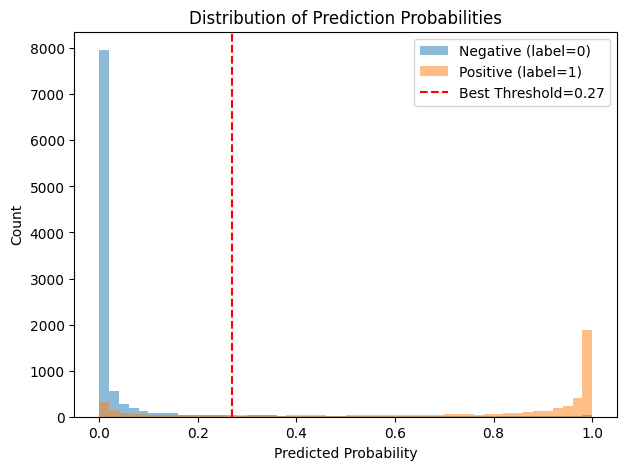

In [5]:
import matplotlib.pyplot as plt
import numpy as np

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

plt.figure(figsize=(7,5))
plt.hist(all_probs[all_labels==0], bins=50, alpha=0.5, label="Negative (label=0)")
plt.hist(all_probs[all_labels==1], bins=50, alpha=0.5, label="Positive (label=1)")
plt.axvline(x=best_thr, color="red", linestyle="--", label=f"Best Threshold={best_thr}")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.title("Distribution of Prediction Probabilities")
plt.legend()
plt.show()